# AI Predictive Maintenance
## Isolation Forest — Anomaly Detection

**Logic:**
- `fan_speed_1/2/3` = พัดลมทำงานปกติที่ความเร็วต่างกัน → เทรน model ให้รู้ว่า normal เป็นยังไง
- `fail_data_speed_1/2/3` = พัดลมทำงานผิดปกติ (fail condition) → ใช้ evaluate model
- `drain_test` = ทดสอบแบตหมด speed 3 → ดูพฤติกรรม health score เมื่อ voltage ตก
- เมื่อ deploy จริง ถ้าค่าผิดปกติจาก normal pattern → anomaly

**Sensors:**
- INA226 → `voltage_V`, `current_mA`
- MPU-6050 → `accel_x`, `accel_y`, `accel_z`

**Engineered features:**
- `vibration_rms` = √(x² + y² + z²)
- `power_W` = voltage × current / 1000

---
## 1. Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../output', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('Libraries OK')

Libraries OK


---
## 2. Load Data

In [29]:
COLUMNS = ['timestamp', 'voltage_V', 'current_mA', 'accel_x', 'accel_y', 'accel_z']

# ── Normal data (fan running at 3 speeds) ───────────────────────────────────
df1 = pd.read_csv('../dataset/fan_speed_1.csv', header=None, names=COLUMNS)
df2 = pd.read_csv('../dataset/fan_speed_2.csv', header=None, names=COLUMNS)
df3 = pd.read_csv('../dataset/fan_speed_3.csv', header=None, names=COLUMNS)

df1['speed'] = 1
df2['speed'] = 2
df3['speed'] = 3

df = pd.concat([df1, df2, df3], ignore_index=True)

# ── Fail data ────────────────────────────────────────────────────────────────
# fail_speed_1 และ _2 มี ESP32 boot log 11 บรรทัดแรก → skiprows=11
# fail_speed_3 ไม่มี boot log
df_f1 = pd.read_csv('../dataset/fail_data_speed_1.csv', header=None, names=COLUMNS, skiprows=11)
df_f2 = pd.read_csv('../dataset/fail_data_speed_2.csv', header=None, names=COLUMNS, skiprows=11)
df_f3 = pd.read_csv('../dataset/fail_data_speed_3.csv', header=None, names=COLUMNS)

df_f1['speed'] = 1
df_f2['speed'] = 2
df_f3['speed'] = 3

df_fail = pd.concat([df_f1, df_f2, df_f3], ignore_index=True)

# ── Drain test (speed 3, battery run-down) ───────────────────────────────────
df_drain = pd.read_csv('../dataset/drain_test.csv', header=None, names=COLUMNS)

print(f'Normal data : {len(df):,} rows')
print(f'Fail data   : {len(df_fail):,} rows')
print(f'Drain test  : {len(df_drain):,} rows')
print()
print('Normal rows per speed:')
print(df['speed'].value_counts().sort_index())
print()
print('Fail rows per speed:')
print(df_fail['speed'].value_counts().sort_index())

Normal data : 359,967 rows
Fail data   : 374,967 rows
Drain test  : 553,903 rows

Normal rows per speed:
speed
1    119989
2    119989
3    119989
Name: count, dtype: int64

Fail rows per speed:
speed
1    124989
2    124989
3    124989
Name: count, dtype: int64


In [30]:
# ── Timestamp coverage ───────────────────────────────────────────────────────
print('Normal — Timestamp coverage per speed:')
for speed in [1, 2, 3]:
    subset = df[df['speed'] == speed]
    interval = subset['timestamp'].diff().median()
    print(f'  Speed {speed}: {subset.timestamp.min():.0f} → {subset.timestamp.max():.0f} ms'
          f' = {subset.timestamp.max()/1000/60:.1f} min | interval ≈ {interval:.0f} ms')

print()
print('Fail — Timestamp coverage per speed:')  # ← เพิ่ม
for speed in [1, 2, 3]:
    subset = df_fail[df_fail['speed'] == speed]
    interval = subset['timestamp'].diff().median()
    print(f'  Speed {speed}: {subset.timestamp.min():.0f} → {subset.timestamp.max():.0f} ms'
          f' = {subset.timestamp.max()/1000/60:.1f} min | interval ≈ {interval:.0f} ms')

print()
print('Drain test:')
print(f'  Duration: {df_drain.timestamp.max()/1000/60:.1f} min  |  rows: {len(df_drain):,}')


Normal — Timestamp coverage per speed:
  Speed 1: 1 → 1439857 ms = 24.0 min | interval ≈ 12 ms
  Speed 2: 1 → 1439857 ms = 24.0 min | interval ≈ 12 ms
  Speed 3: 1 → 1439857 ms = 24.0 min | interval ≈ 12 ms

Fail — Timestamp coverage per speed:
  Speed 1: 1 → 1499857 ms = 25.0 min | interval ≈ 12 ms
  Speed 2: 1 → 1499857 ms = 25.0 min | interval ≈ 12 ms
  Speed 3: 1 → 1499857 ms = 25.0 min | interval ≈ 12 ms

Drain test:
  Duration: 110.8 min  |  rows: 553,903


---
## 3. Feature Engineering

In [31]:
def add_features(df_in):
    d = df_in.copy()
    d['vibration_rms'] = np.sqrt(d['accel_x']**2 + d['accel_y']**2 + d['accel_z']**2)
    d['power_W']       = d['voltage_V'] * d['current_mA'] / 1000
    return d

df       = add_features(df)
df_fail  = add_features(df_fail)
df_drain = add_features(df_drain)

df_drain['time_min'] = df_drain['timestamp'] / 1000 / 60

print('Features added: vibration_rms, power_W')
df[['voltage_V', 'current_mA', 'vibration_rms', 'power_W']].describe().round(3)

Features added: vibration_rms, power_W


,voltage_V,current_mA,vibration_rms,power_W
count,359967.000,359967.000,359967.000,359967.000
mean,7.071,258.746,10.339,2.008
std,2.075,98.526,1.023,1.267
min,3.910,119.470,6.395,0.554
25%,4.990,173.020,9.719,0.801
50%,6.850,230.430,10.021,1.549
75%,9.430,336.600,10.868,3.208
max,10.520,517.830,19.828,5.284


---
## 4. EDA — Normal Data (3 Speeds)

In [32]:
# ── 4.1 Summary statistics per speed ────────────────────────────────────────
summary = df.groupby('speed')[['voltage_V', 'current_mA', 'power_W', 'vibration_rms']].mean().round(3)
print('Average per speed (normal):')
print(summary)

Average per speed (normal):
       voltage_V  current_mA  power_W  vibration_rms
speed                                               
1          4.737     160.192    0.755          9.816
2          6.758     242.618    1.637         10.052
3          9.716     373.428    3.632         11.149


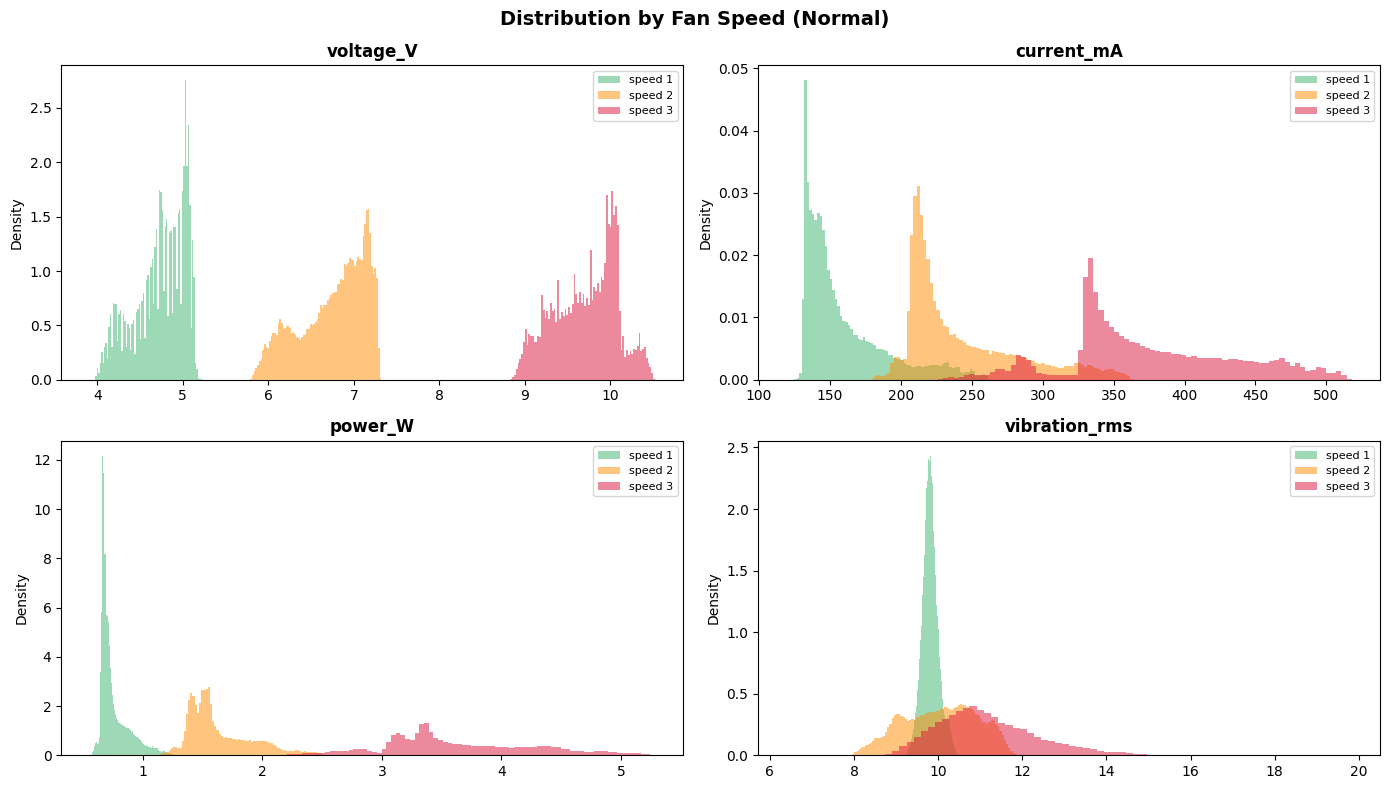

In [33]:
# ── 4.2 Distribution per feature ────────────────────────────────────────────
FEATURES_PLOT = ['voltage_V', 'current_mA', 'power_W', 'vibration_rms']
colors = {1: 'mediumseagreen', 2: 'darkorange', 3: 'crimson'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES_PLOT):
    for speed, color in colors.items():
        axes[i].hist(df[df['speed'] == speed][feat], bins=80, alpha=0.5,
                     color=color, label=f'speed {speed}', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution by Fan Speed (Normal)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_distribution.png', dpi=150)
plt.show()

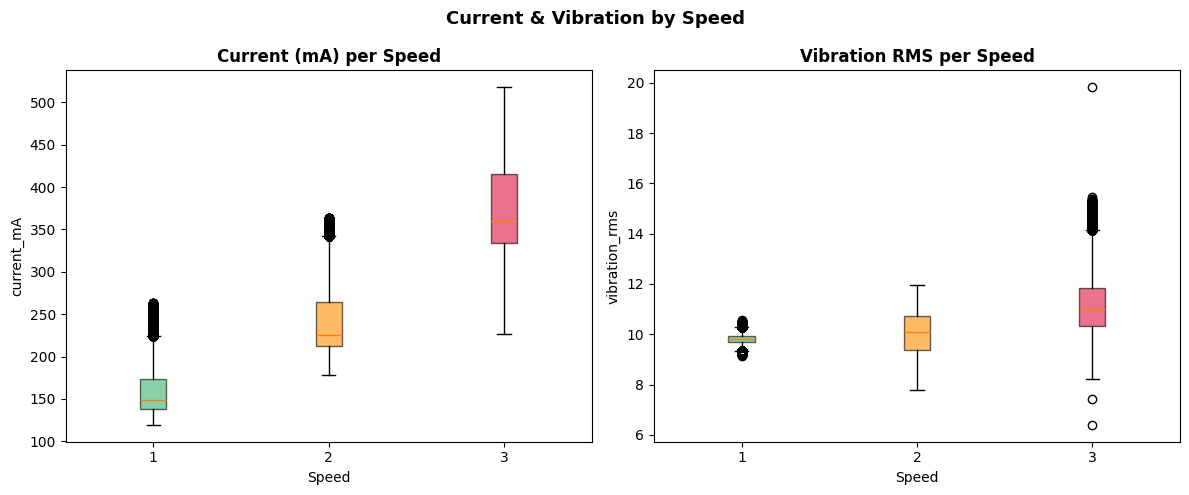

In [34]:
# ── 4.3 Boxplot: Current & Vibration per Speed ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for speed, color in colors.items():
    subset = df[df['speed'] == speed]
    axes[0].boxplot(subset['current_mA'], positions=[speed], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6))
    axes[1].boxplot(subset['vibration_rms'], positions=[speed], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6))

for ax, title, ylabel in zip(axes,
    ['Current (mA) per Speed', 'Vibration RMS per Speed'],
    ['current_mA', 'vibration_rms']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Speed')
    ax.set_ylabel(ylabel)

plt.suptitle('Current & Vibration by Speed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_boxplot.png', dpi=150)
plt.show()

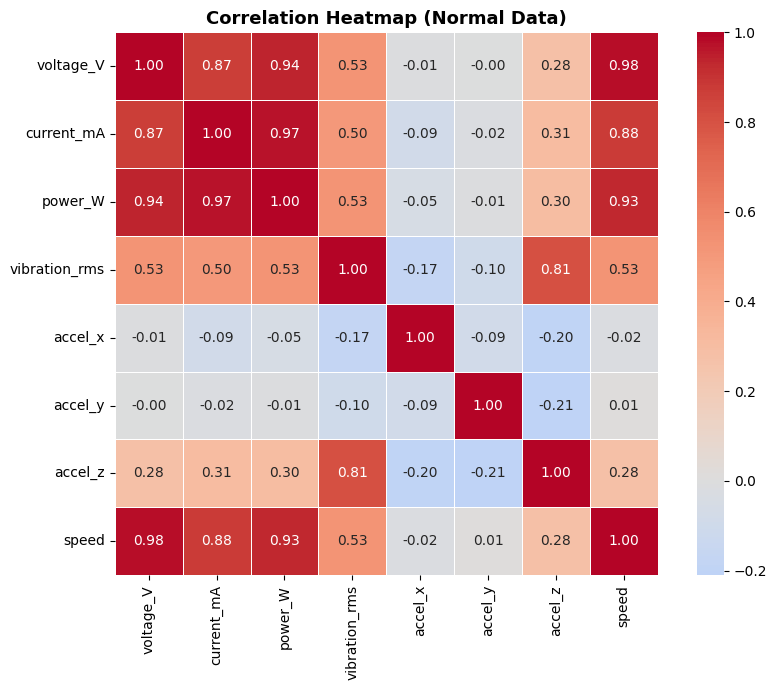

In [35]:
# ── 4.4 Correlation Heatmap ──────────────────────────────────────────────────
corr_cols = ['voltage_V', 'current_mA', 'power_W', 'vibration_rms',
             'accel_x', 'accel_y', 'accel_z', 'speed']
corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Normal Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/correlation_heatmap.png', dpi=150)
plt.show()

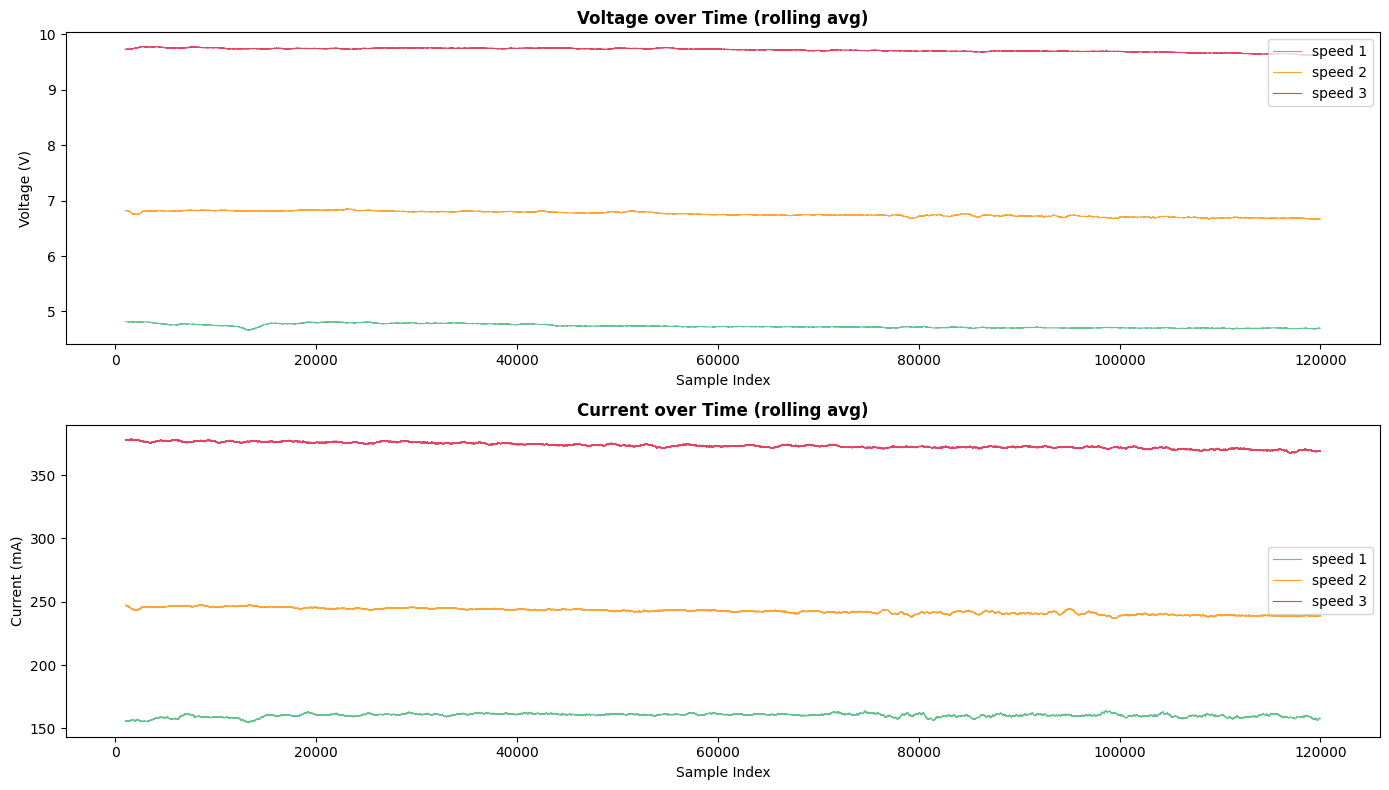

In [36]:
# ── 4.5 Time-series: Voltage & Current (rolling avg) ────────────────────────
# NOTE: All speeds share the same timestamp range (millis() resets each recording).
# Using sample index instead of raw timestamp to avoid overlapping x-axis.
window = 1000
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for speed, color in colors.items():
    subset = df[df['speed'] == speed].reset_index(drop=True)
    axes[0].plot(subset.index, subset['voltage_V'].rolling(window).mean(),
                 color=color, alpha=0.8, label=f'speed {speed}', linewidth=0.8)
    axes[1].plot(subset.index, subset['current_mA'].rolling(window).mean(),
                 color=color, alpha=0.8, label=f'speed {speed}', linewidth=0.8)

axes[0].set_title('Voltage over Time (rolling avg)', fontweight='bold')
axes[0].set_ylabel('Voltage (V)')
axes[0].set_xlabel('Sample Index')
axes[0].legend()
axes[1].set_title('Current over Time (rolling avg)', fontweight='bold')
axes[1].set_ylabel('Current (mA)')
axes[1].set_xlabel('Sample Index')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/timeseries.png', dpi=150)
plt.show()


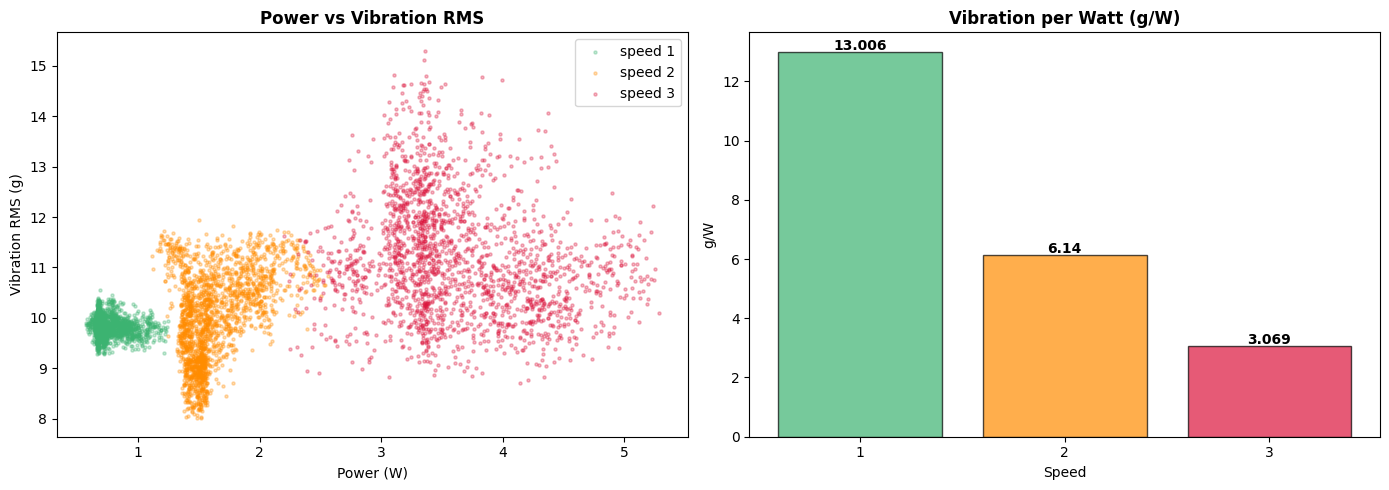

In [37]:
# ── 4.6 Power vs Vibration scatter + Efficiency bar ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for speed, color in colors.items():
    subset = df[df['speed'] == speed].sample(2000, random_state=42)
    axes[0].scatter(subset['power_W'], subset['vibration_rms'],
                    color=color, alpha=0.3, s=5, label=f'speed {speed}')

axes[0].set_title('Power vs Vibration RMS', fontweight='bold')
axes[0].set_xlabel('Power (W)')
axes[0].set_ylabel('Vibration RMS (g)')
axes[0].legend()

efficiency = df.groupby('speed').apply(
    lambda x: x['vibration_rms'].mean() / x['power_W'].mean()).round(3)

bar_colors = [colors[s] for s in efficiency.index]
axes[1].bar(efficiency.index.astype(str), efficiency.values,
            color=bar_colors, alpha=0.7, edgecolor='black')
axes[1].set_title('Vibration per Watt (g/W)', fontweight='bold')
axes[1].set_xlabel('Speed')
axes[1].set_ylabel('g/W')
for i, v in enumerate(efficiency.values):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/power_efficiency.png', dpi=150)
plt.show()

---
## 5. EDA — Normal vs Fail

In [38]:
# ── 5.1 Summary: Normal vs Fail per speed ────────────────────────────────────
FEATURES_COMPARE = ['voltage_V', 'current_mA', 'vibration_rms', 'power_W']

s_norm = df.groupby('speed')[FEATURES_COMPARE].mean().round(3)
s_fail = df_fail.groupby('speed')[FEATURES_COMPARE].mean().round(3)

print('Normal (mean per speed):')
print(s_norm)
print('\nFail (mean per speed):')
print(s_fail)
print('\nDelta = Fail − Normal:')
print((s_fail - s_norm).round(3))

Normal (mean per speed):
       voltage_V  current_mA  vibration_rms  power_W
speed                                               
1          4.737     160.192          9.816    0.755
2          6.758     242.618         10.052    1.637
3          9.716     373.428         11.149    3.632

Fail (mean per speed):
       voltage_V  current_mA  vibration_rms  power_W
speed                                               
1          5.002     190.779          9.905    0.949
2          7.243     291.708          9.975    2.113
3          9.432     388.492         10.159    3.675

Delta = Fail − Normal:
       voltage_V  current_mA  vibration_rms  power_W
speed                                               
1          0.265      30.587          0.089    0.194
2          0.485      49.090         -0.077    0.476
3         -0.284      15.064         -0.990    0.043


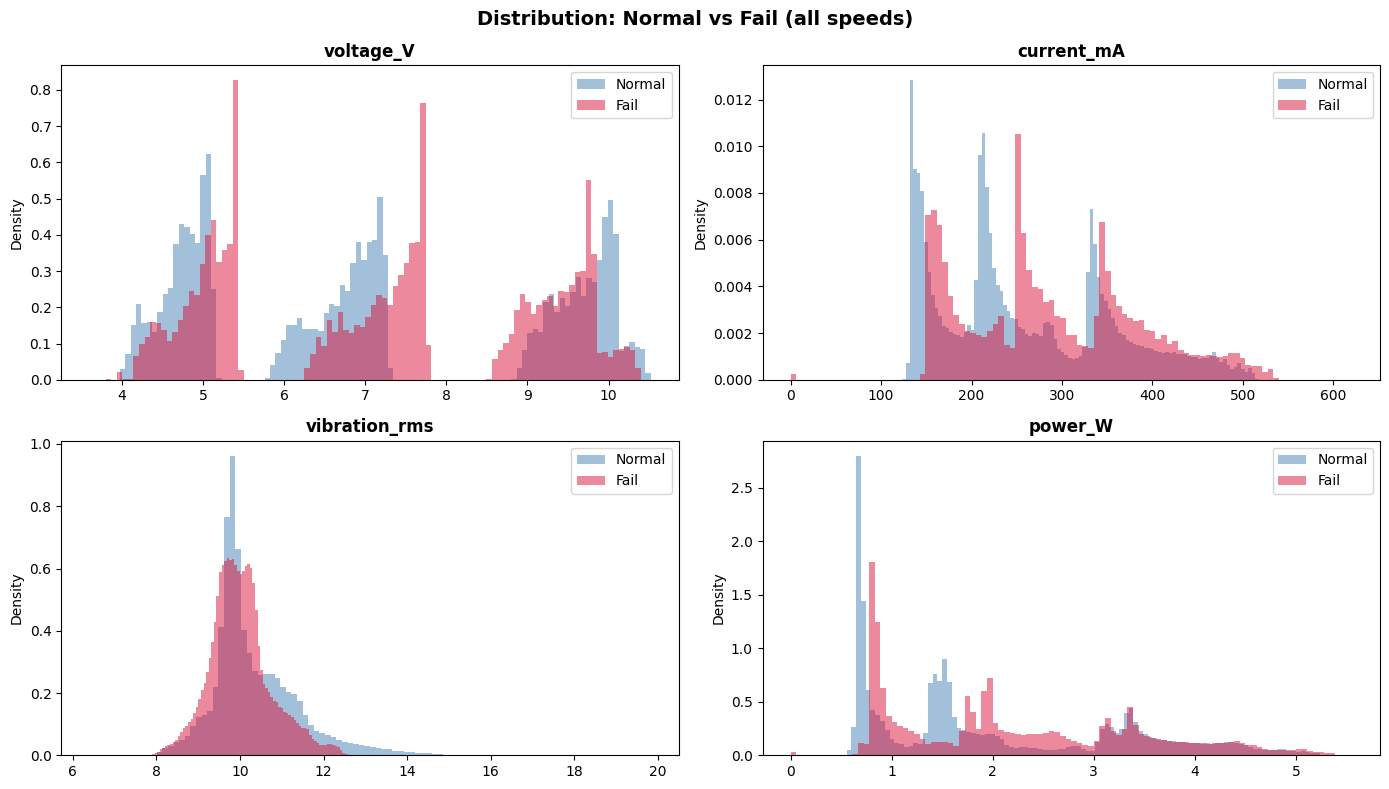

In [39]:
# ── 5.2 Distribution: Normal vs Fail — all speeds combined ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES_COMPARE):
    axes[i].hist(df[feat],      bins=100, alpha=0.5, color='steelblue',
                 label='Normal', density=True)
    axes[i].hist(df_fail[feat], bins=100, alpha=0.5, color='crimson',
                 label='Fail',   density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Distribution: Normal vs Fail (all speeds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_normal_vs_fail_dist.png', dpi=150)
plt.show()

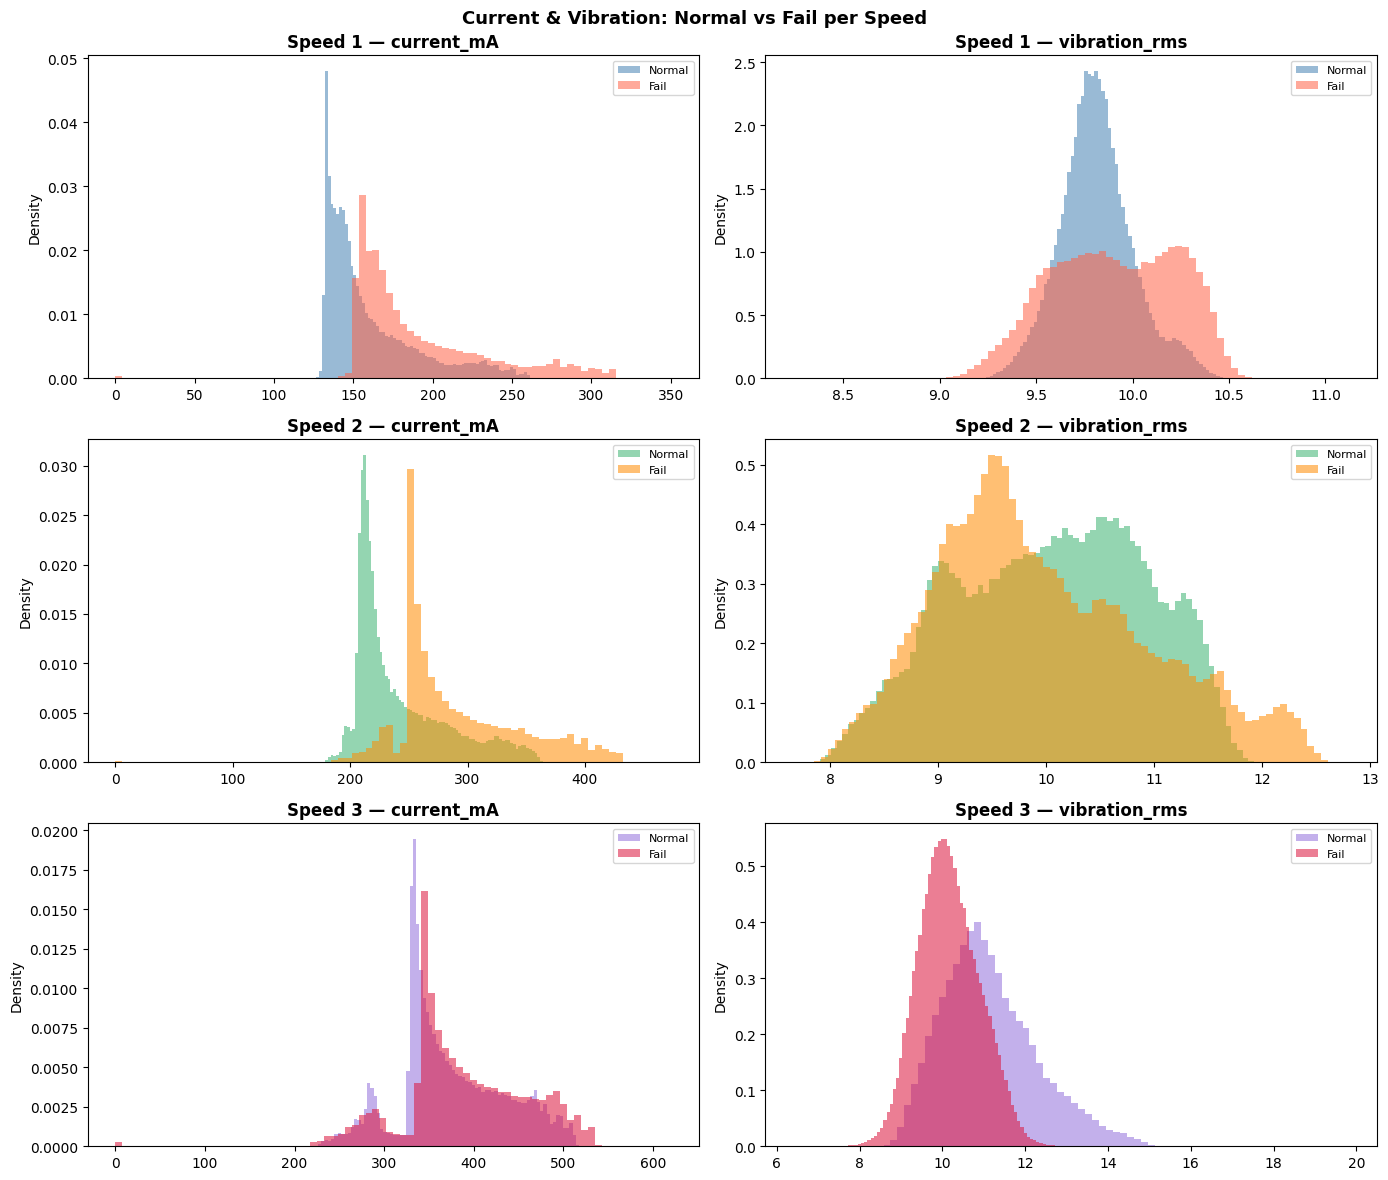

In [40]:
# ── 5.3 Current & Vibration distribution per speed ──────────────────────────
speed_palette = {1: ('steelblue', 'tomato'),
                 2: ('mediumseagreen', 'darkorange'),
                 3: ('mediumpurple', 'crimson')}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, speed in enumerate([1, 2, 3]):
    norm_sub = df[df['speed'] == speed]
    fail_sub = df_fail[df_fail['speed'] == speed]
    c_n, c_f = speed_palette[speed]
    for col, feat in enumerate(['current_mA', 'vibration_rms']):
        axes[row, col].hist(norm_sub[feat], bins=80, alpha=0.55,
                            color=c_n, label='Normal', density=True)
        axes[row, col].hist(fail_sub[feat], bins=80, alpha=0.55,
                            color=c_f, label='Fail',   density=True)
        axes[row, col].set_title(f'Speed {speed} — {feat}', fontweight='bold')
        axes[row, col].set_ylabel('Density')
        axes[row, col].legend(fontsize=8)

plt.suptitle('Current & Vibration: Normal vs Fail per Speed',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_per_speed_fail.png', dpi=150)
plt.show()

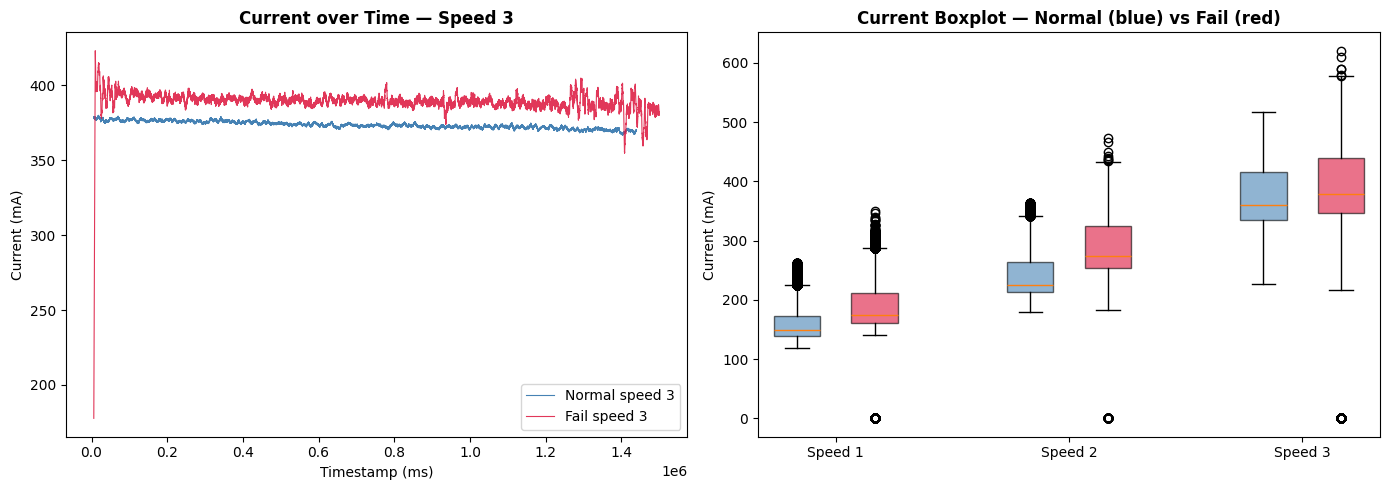

Current ≤ 0 mA rows (noise / drop):
  Speed 1 → Normal: 0  |  Fail: 167
  Speed 2 → Normal: 0  |  Fail: 70
  Speed 3 → Normal: 0  |  Fail: 238


In [41]:
# ── 5.4 Current spike / drop analysis ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
window = 500

# Time-series current speed 3
norm3 = df[df['speed'] == 3].reset_index(drop=True)
fail3 = df_fail[df_fail['speed'] == 3].reset_index(drop=True)

axes[0].plot(norm3['timestamp'], norm3['current_mA'].rolling(window).mean(),
             color='steelblue', linewidth=0.8, label='Normal speed 3')
axes[0].plot(fail3['timestamp'], fail3['current_mA'].rolling(window).mean(),
             color='crimson',   linewidth=0.8, label='Fail speed 3', alpha=0.85)
axes[0].set_title('Current over Time — Speed 3', fontweight='bold')
axes[0].set_xlabel('Timestamp (ms)')
axes[0].set_ylabel('Current (mA)')
axes[0].legend()

# Boxplot current all speeds
pos_n = [1, 4, 7]
pos_f = [2, 5, 8]
for idx, speed in enumerate([1, 2, 3]):
    axes[1].boxplot(df[df['speed']==speed]['current_mA'],
                    positions=[pos_n[idx]], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6), widths=0.6)
    axes[1].boxplot(df_fail[df_fail['speed']==speed]['current_mA'],
                    positions=[pos_f[idx]], patch_artist=True,
                    boxprops=dict(facecolor='crimson',   alpha=0.6), widths=0.6)

axes[1].set_xticks([1.5, 4.5, 7.5])
axes[1].set_xticklabels(['Speed 1', 'Speed 2', 'Speed 3'])
axes[1].set_title('Current Boxplot — Normal (blue) vs Fail (red)', fontweight='bold')
axes[1].set_ylabel('Current (mA)')

plt.tight_layout()
plt.savefig('../output/eda_current_fail_analysis.png', dpi=150)
plt.show()

print('Current ≤ 0 mA rows (noise / drop):')
for speed in [1, 2, 3]:
    n = (df[df['speed']==speed]['current_mA'] <= 0).sum()
    f = (df_fail[df_fail['speed']==speed]['current_mA'] <= 0).sum()
    print(f'  Speed {speed} → Normal: {n:,}  |  Fail: {f:,}')

---
## 6. EDA — Drain Test (Battery Voltage Drop)

In [42]:
# ── 6.1 Overview ─────────────────────────────────────────────────────────────
print(f'Duration : {df_drain.time_min.max():.1f} min  ({df_drain.time_min.max()/60:.2f} h)')
print(f'Rows     : {len(df_drain):,}')
print(f'Voltage  : {df_drain.voltage_V.min():.2f}V → {df_drain.voltage_V.max():.2f}V')
df_drain[['voltage_V', 'current_mA', 'power_W', 'vibration_rms']].describe().round(3)

Duration : 110.8 min  (1.85 h)
Rows     : 553,903
Voltage  : 3.15V → 10.08V


,voltage_V,current_mA,power_W,vibration_rms
count,553903.000,553903.000,553903.000,553903.000
mean,8.701,321.411,2.825,10.146
std,0.894,61.813,0.691,0.879
min,3.150,-0.050,-0.000,7.772
25%,8.350,280.950,2.409,9.496
50%,8.870,312.870,2.810,10.050
75%,9.310,360.980,3.239,10.720
max,10.080,486.770,4.784,13.167


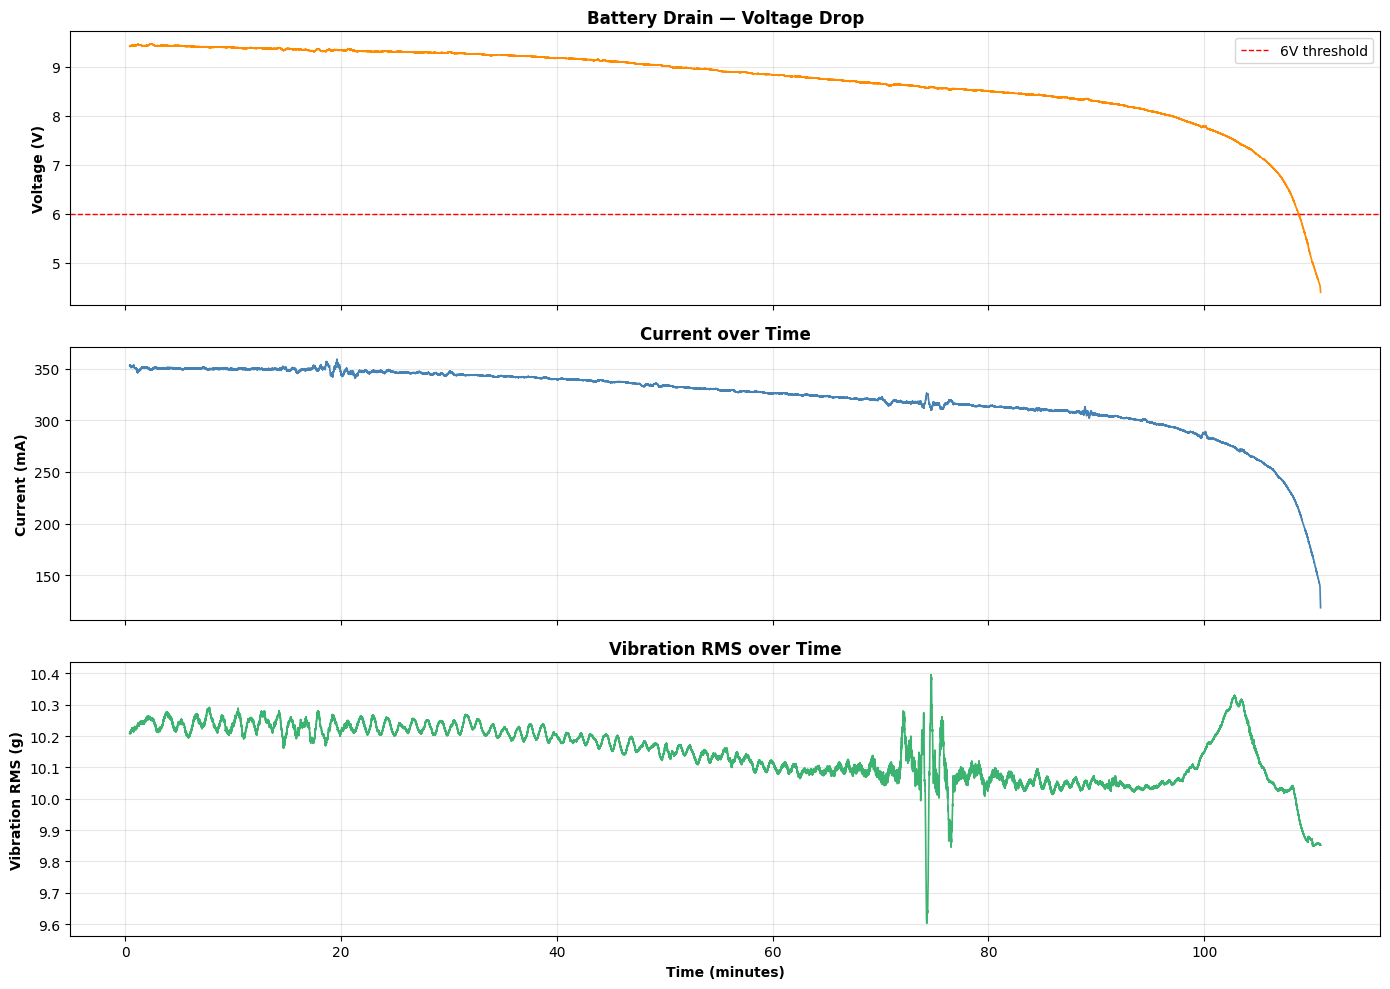

In [43]:
# ── 6.2 Voltage, Current, Vibration over Time ────────────────────────────────
win = 2000
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_drain['time_min'],
             df_drain['voltage_V'].rolling(win).mean(),
             color='darkorange', linewidth=1.2)
axes[0].axhline(6.0, color='red', linestyle='--', linewidth=1, label='6V threshold')
axes[0].set_ylabel('Voltage (V)', fontweight='bold')
axes[0].set_title('Battery Drain — Voltage Drop', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_drain['time_min'],
             df_drain['current_mA'].rolling(win).mean(),
             color='steelblue', linewidth=1.2)
axes[1].set_ylabel('Current (mA)', fontweight='bold')
axes[1].set_title('Current over Time', fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(df_drain['time_min'],
             df_drain['vibration_rms'].rolling(win).mean(),
             color='mediumseagreen', linewidth=1.2)
axes[2].set_ylabel('Vibration RMS (g)', fontweight='bold')
axes[2].set_title('Vibration RMS over Time', fontweight='bold')
axes[2].set_xlabel('Time (minutes)', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../output/drain_test_timeseries.png', dpi=150)
plt.show()

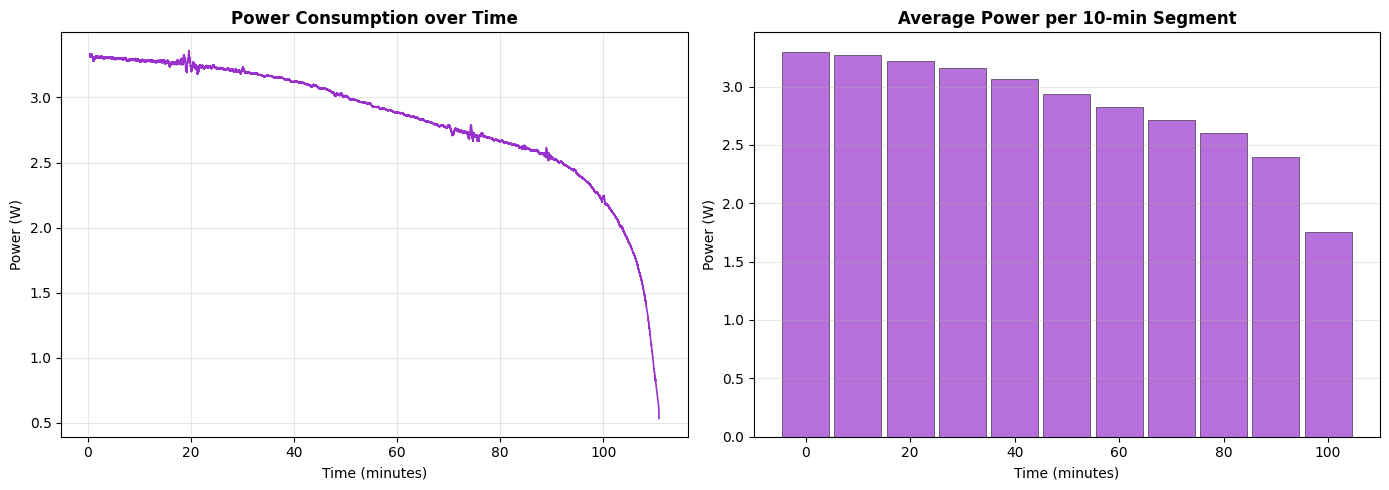

10-min segment summary:
 time_start  voltage_mean  current_mean  power_mean  vib_mean
          0         9.416       350.117       3.299    10.239
         10         9.354       349.563       3.272    10.232
         20         9.304       346.054       3.222    10.230
         30         9.229       342.341       3.162    10.218
         40         9.102       336.898       3.069    10.177
         50         8.917       329.395       2.939    10.131
         60         8.741       322.854       2.824    10.092
         70         8.572       315.992       2.710    10.080
         80         8.404       309.942       2.606    10.053
         90         8.064       296.597       2.393    10.058
        100         6.925       250.253       1.754    10.115


In [44]:
# ── 6.3 Power over Time + 10-min segment summary ─────────────────────────────
total_min = df_drain['time_min'].max()

seg_data = []
for t in range(0, int(total_min), 10):
    seg = df_drain[(df_drain['time_min'] >= t) & (df_drain['time_min'] < t + 10)]
    if len(seg) > 100:
        seg_data.append({'time_start'  : t,
                         'voltage_mean': seg['voltage_V'].mean(),
                         'current_mean': seg['current_mA'].mean(),
                         'power_mean'  : seg['power_W'].mean(),
                         'vib_mean'    : seg['vibration_rms'].mean()})
df_seg = pd.DataFrame(seg_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_drain['time_min'], df_drain['power_W'].rolling(win).mean(),
             color='darkorchid', linewidth=1.2)
axes[0].set_title('Power Consumption over Time', fontweight='bold')
axes[0].set_xlabel('Time (minutes)')
axes[0].set_ylabel('Power (W)')
axes[0].grid(alpha=0.3)

axes[1].bar(df_seg['time_start'], df_seg['power_mean'],
            width=9, color='darkorchid', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_title('Average Power per 10-min Segment', fontweight='bold')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_ylabel('Power (W)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/drain_test_power.png', dpi=150)
plt.show()

print('10-min segment summary:')
print(df_seg.round(3).to_string(index=False))

---
## 7. Train Isolation Forest (Normal Data Only)

In [45]:
FEATURES = ['voltage_V', 'current_mA', 'vibration_rms', 'power_W']

# ── Train one Isolation Forest per speed (contamination=0.01) ───────────────
# Rationale:
#   1. Each speed has distinct voltage/current range → global scaler distorts boundaries
#   2. contamination=0.01 is more appropriate for clean normal-only training data
#      (0.05 would force 18k normal rows to be treated as anomaly during training)

per_speed_models  = {}
per_speed_scalers = {}
SCORE_MINS = {}
SCORE_MAXS = {}

for speed in [1, 2, 3]:
    sub = df[df['speed'] == speed][FEATURES]
    sc  = StandardScaler()
    Xs  = sc.fit_transform(sub)
    m   = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
    m.fit(Xs)
    raw = m.score_samples(Xs)
    per_speed_models[speed]  = m
    per_speed_scalers[speed] = sc
    SCORE_MINS[speed] = raw.min()
    SCORE_MAXS[speed] = raw.max()
    print(f'Speed {speed}: trained on {len(sub):,} samples  '
          f'| score range [{raw.min():.4f}, {raw.max():.4f}]')

print(f'\nFeatures : {FEATURES}')


Speed 1: trained on 119,989 samples  | score range [-0.7072, -0.3756]
Speed 2: trained on 119,989 samples  | score range [-0.6703, -0.3944]
Speed 3: trained on 119,989 samples  | score range [-0.6870, -0.3931]

Features : ['voltage_V', 'current_mA', 'vibration_rms', 'power_W']


---
## 8. Health Score — Normal Data

In [46]:
# ── คำนวณ health score per speed จาก per-speed models ──────────────────────
def to_health_score(raw, speed):
    smin, smax = SCORE_MINS[speed], SCORE_MAXS[speed]
    return np.round(
        (np.clip(raw, smin, smax) - smin) / (smax - smin) * 100, 1)

for speed in [1, 2, 3]:
    mask = df['speed'] == speed
    sub  = df.loc[mask, FEATURES]
    Xs   = per_speed_scalers[speed].transform(sub)
    df.loc[mask, 'health_score'] = to_health_score(
        per_speed_models[speed].score_samples(Xs), speed)
    df.loc[mask, 'anomaly'] = per_speed_models[speed].predict(Xs)

print('Health score per speed (normal data):')
print(df.groupby('speed')['health_score'].describe().round(2))
print()
print('False-positive rate (normal rows flagged as anomaly):')
for speed in [1, 2, 3]:
    sub = df[df['speed'] == speed]
    fp  = (sub['anomaly'] == -1).sum()
    print(f'  Speed {speed}: {fp:,}/{len(sub):,} = {fp/len(sub)*100:.1f}%')


Health score per speed (normal data):
          count   mean    std  min   25%   50%   75%    max
speed                                                      
1      119989.0  73.46  18.78  0.0  61.0  77.9  89.4  100.0
2      119989.0  71.18  19.10  0.0  59.1  74.9  87.1  100.0
3      119989.0  72.40  16.55  0.0  61.9  75.6  85.4  100.0

False-positive rate (normal rows flagged as anomaly):
  Speed 1: 1,200/119,989 = 1.0%
  Speed 2: 1,200/119,989 = 1.0%
  Speed 3: 1,200/119,989 = 1.0%


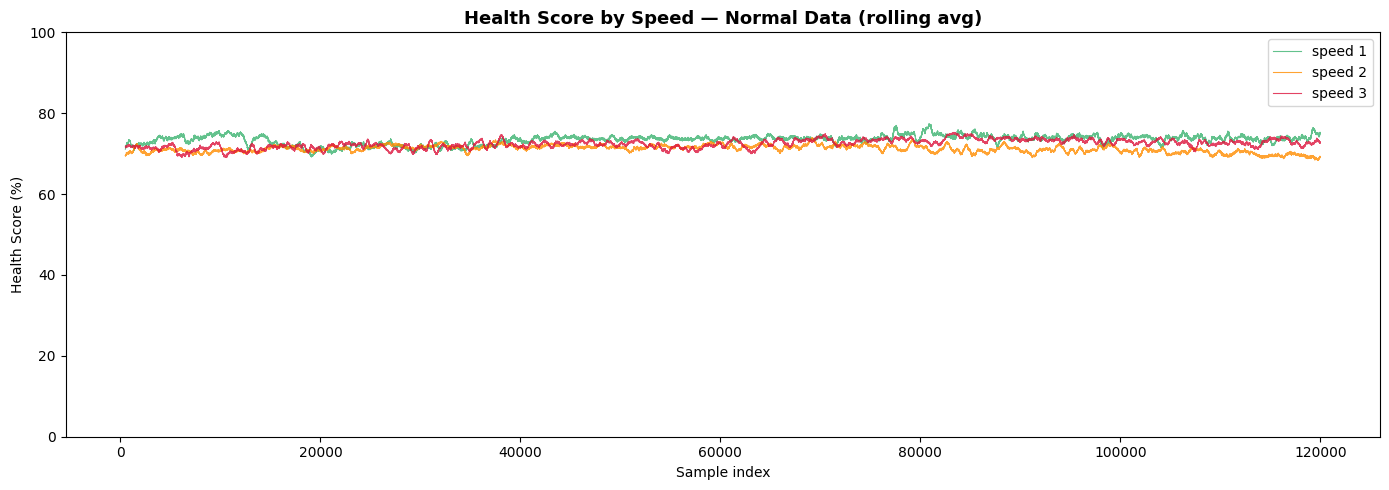

In [47]:
# ── Health score over time per speed ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
window = 500

for speed, color in colors.items():
    subset = df[df['speed'] == speed].reset_index(drop=True)
    ax.plot(subset['health_score'].rolling(window).mean(),
            color=color, alpha=0.8, label=f'speed {speed}', linewidth=0.8)

ax.set_ylim(0, 100)
ax.set_title('Health Score by Speed — Normal Data (rolling avg)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Health Score (%)')
ax.set_xlabel('Sample index')
ax.legend()
plt.tight_layout()
plt.savefig('../output/health_score.png', dpi=150)
plt.show()

---
## 9. Anomaly Detection Evaluation — Fail Data

In [48]:
# ── 9.1 Predict on fail data (per-speed model) ───────────────────────────────
for speed in [1, 2, 3]:
    mask = df_fail['speed'] == speed
    sub  = df_fail.loc[mask, FEATURES]
    Xs   = per_speed_scalers[speed].transform(sub)
    df_fail.loc[mask, 'health_score'] = to_health_score(
        per_speed_models[speed].score_samples(Xs), speed)
    df_fail.loc[mask, 'anomaly'] = per_speed_models[speed].predict(Xs)

print('Detection rate on fail data (% flagged as anomaly):')
for speed in [1, 2, 3]:
    sub      = df_fail[df_fail['speed'] == speed]
    detected = (sub['anomaly'] == -1).sum()
    pct      = detected / len(sub) * 100
    print(f'  Speed {speed}: {detected:,}/{len(sub):,} = {pct:.1f}%')

print()
print('Health score on fail data:')
print(df_fail.groupby('speed')['health_score'].describe().round(2))


Detection rate on fail data (% flagged as anomaly):
  Speed 1: 31,876/124,989 = 25.5%
  Speed 2: 34,718/124,989 = 27.8%
  Speed 3: 8,562/124,989 = 6.9%

Health score on fail data:
          count   mean    std  min   25%   50%   75%    max
speed                                                      
1      124989.0  35.61  19.64  0.0  21.1  35.1  48.8   98.1
2      124989.0  35.82  25.19  0.0  13.6  38.5  53.6   99.7
3      124989.0  62.89  21.94  0.0  48.9  64.8  81.0  100.0


Classification Report (1=normal, 0=fail):
              precision    recall  f1-score   support

    Fail (0)       0.95      0.20      0.33    374967
  Normal (1)       0.54      0.99      0.70    359967

    accuracy                           0.59    734934
   macro avg       0.75      0.60      0.52    734934
weighted avg       0.75      0.59      0.51    734934



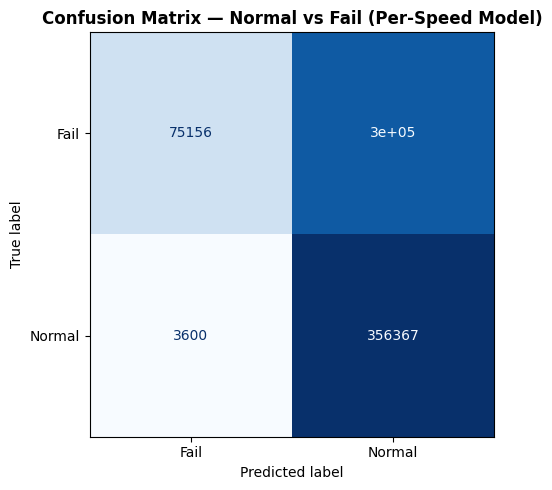

In [49]:
# ── 9.2 Confusion matrix (binary label: normal=1, fail=0) ────────────────────
# ใช้ anomaly column ที่ predict ไว้แล้วใน df และ df_fail (per-speed models)
y_true_norm = np.ones(len(df),       dtype=int)   # normal = 1
y_true_fail = np.zeros(len(df_fail),  dtype=int)  # fail   = 0

y_pred_norm = (df['anomaly'] == 1).astype(int)
y_pred_fail = (df_fail['anomaly'] == 1).astype(int)

y_true_all = np.concatenate([y_true_norm, y_true_fail])
y_pred_all = np.concatenate([y_pred_norm, y_pred_fail])

print('Classification Report (1=normal, 0=fail):')
print(classification_report(y_true_all, y_pred_all,
                             target_names=['Fail (0)', 'Normal (1)']))

cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Fail', 'Normal'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Normal vs Fail (Per-Speed Model)', fontweight='bold')
plt.tight_layout()
plt.savefig('../output/confusion_matrix.png', dpi=150)
plt.show()


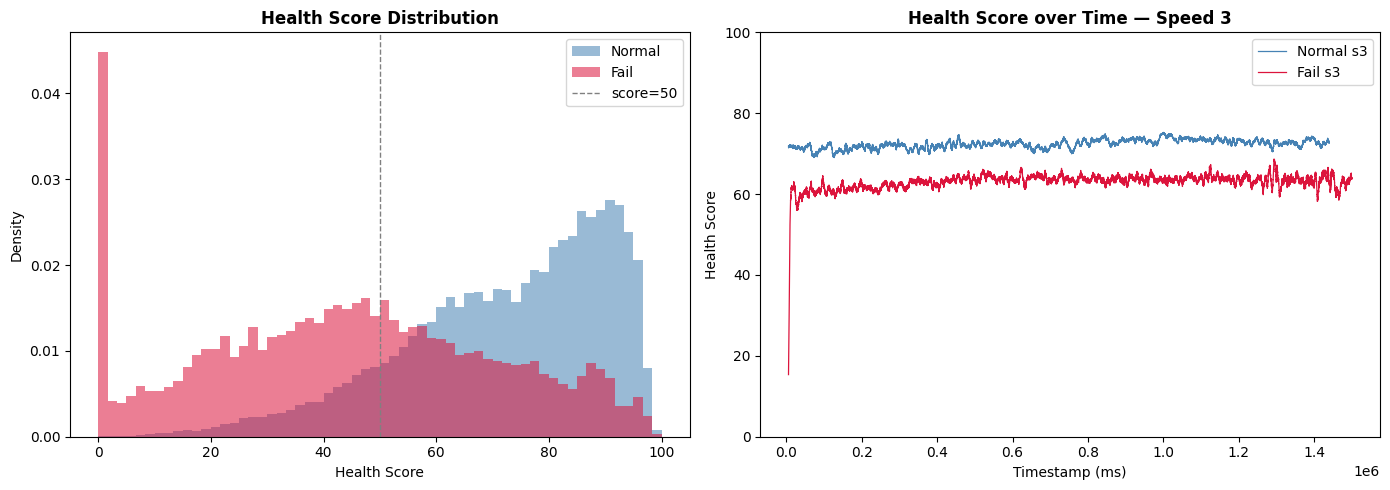

In [50]:
# ── 9.3 Health Score distribution: Normal vs Fail ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['health_score'],      bins=60, alpha=0.55,
             color='steelblue', label='Normal', density=True)
axes[0].hist(df_fail['health_score'], bins=60, alpha=0.55,
             color='crimson',   label='Fail',   density=True)
axes[0].axvline(50, color='gray', linestyle='--', linewidth=1, label='score=50')
axes[0].set_title('Health Score Distribution', fontweight='bold')
axes[0].set_xlabel('Health Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Rolling health score over time — speed 3
window = 500
for label, sub, color in [
    ('Normal s3', df[df['speed']==3].reset_index(drop=True),      'steelblue'),
    ('Fail s3',   df_fail[df_fail['speed']==3].reset_index(drop=True), 'crimson')]:
    axes[1].plot(sub['timestamp'], sub['health_score'].rolling(window).mean(),
                 color=color, linewidth=0.9, label=label)

axes[1].set_ylim(0, 100)
axes[1].set_title('Health Score over Time — Speed 3', fontweight='bold')
axes[1].set_xlabel('Timestamp (ms)')
axes[1].set_ylabel('Health Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/health_score_fail_eval.png', dpi=150)
plt.show()

---
## 10. Health Score — Drain Test

In [51]:
# ── 10.1 Predict on drain test (ใช้ speed-3 model เพราะ drain ทำที่ speed 3) ──
X_drain              = per_speed_scalers[3].transform(df_drain[FEATURES])
df_drain['anomaly']  = per_speed_models[3].predict(X_drain)
df_drain['health_score'] = to_health_score(
    per_speed_models[3].score_samples(X_drain), 3)

# Phase breakdown by voltage
phases = [('High  (>8V)',  df_drain['voltage_V'] >= 8),
          ('Mid  (6-8V)', (df_drain['voltage_V'] >= 6) & (df_drain['voltage_V'] < 8)),
          ('Low   (<6V)',  df_drain['voltage_V'] < 6)]

print('Drain test — anomaly rate and health score by voltage phase:')
for label, mask in phases:
    seg = df_drain[mask]
    if len(seg) == 0:
        continue
    anom = (seg['anomaly'] == -1).mean() * 100
    hs   = seg['health_score'].mean()
    print(f'  {label}: n={len(seg):>7,}  health={hs:.1f}  anomaly_rate={anom:.1f}%')


Drain test — anomaly rate and health score by voltage phase:
  High  (>8V): n=467,704  health=45.5  anomaly_rate=23.5%
  Mid  (6-8V): n= 74,646  health=14.3  anomaly_rate=84.3%
  Low   (<6V): n= 11,553  health=4.1  anomaly_rate=98.8%


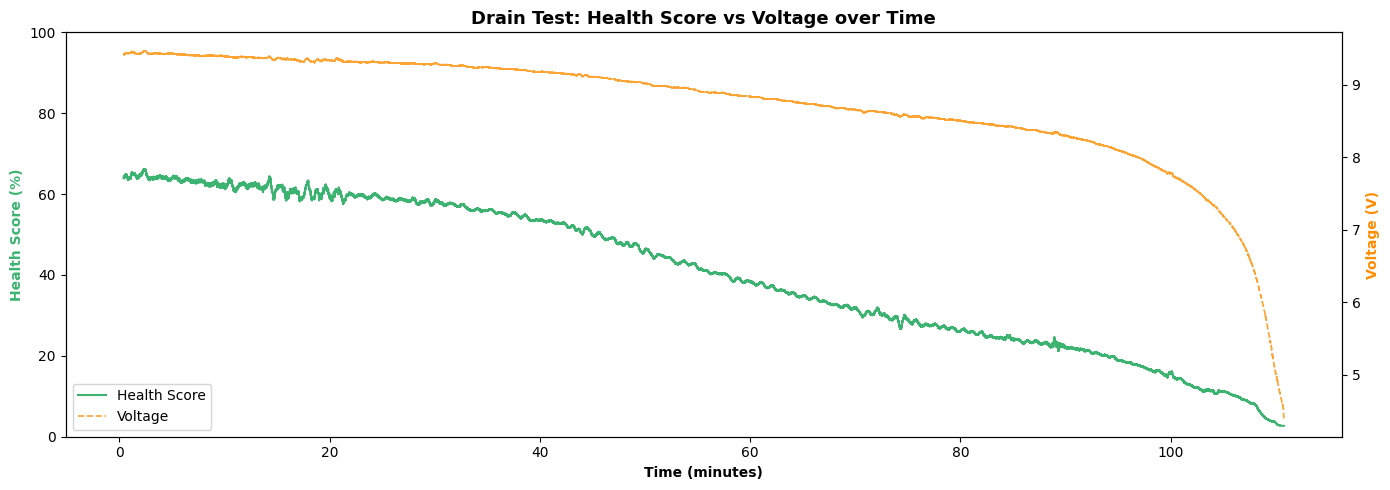

Anomaly rate  first 60 min : 8.3%  health=55.2
Anomaly rate  last  51 min : 62.8%  health=22.9


In [52]:
# ── 10.2 Health Score vs Voltage — dual axis ──────────────────────────────────
win = 2000
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df_drain['time_min'],
         df_drain['health_score'].rolling(win).mean(),
         color='mediumseagreen', linewidth=1.5, label='Health Score', zorder=3)
ax2.plot(df_drain['time_min'],
         df_drain['voltage_V'].rolling(win).mean(),
         color='darkorange', linewidth=1.2, linestyle='--', label='Voltage', alpha=0.8)

ax1.set_xlabel('Time (minutes)', fontweight='bold')
ax1.set_ylabel('Health Score (%)', color='mediumseagreen', fontweight='bold')
ax2.set_ylabel('Voltage (V)',      color='darkorange',     fontweight='bold')
ax1.set_ylim(0, 100)

lines  = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left')

plt.title('Drain Test: Health Score vs Voltage over Time',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/drain_test_health_score.png', dpi=150)
plt.show()

# Early vs late anomaly rate
early = df_drain[df_drain['time_min'] < 60]
late  = df_drain[df_drain['time_min'] >= 60]
print(f'Anomaly rate  first 60 min : {(early["anomaly"]==-1).mean()*100:.1f}%  '
      f'health={early["health_score"].mean():.1f}')
print(f'Anomaly rate  last  {df_drain.time_min.max()-60:.0f} min : '
      f'{(late["anomaly"]==-1).mean()*100:.1f}%  '
      f'health={late["health_score"].mean():.1f}')

---
## 11. Save Model & Export CSV

In [53]:
# ── 11.1 Save per-speed models + scalers ────────────────────────────────────
for speed in [1, 2, 3]:
    joblib.dump(per_speed_models[speed],
                f'../models/isolation_forest_speed{speed}.pkl')
    joblib.dump(per_speed_scalers[speed],
                f'../models/scaler_speed{speed}.pkl')

# ── 11.2 Export CSV for Power BI ─────────────────────────────────────────────
EXPORT_COLS = ['timestamp', 'speed', 'voltage_V', 'current_mA',
               'vibration_rms', 'power_W', 'health_score', 'anomaly']

df_all = pd.concat([
    df[EXPORT_COLS].assign(label='normal'),
    df_fail[EXPORT_COLS].assign(label='fail')
], ignore_index=True)

df[EXPORT_COLS].to_csv('../output/health_scores_normal.csv', index=False)
df_fail[EXPORT_COLS].to_csv('../output/health_scores_fail.csv', index=False)
df_all.to_csv('../output/health_scores_all.csv', index=False)

drain_export = df_drain[['timestamp', 'time_min', 'voltage_V', 'current_mA',
                          'vibration_rms', 'power_W', 'health_score', 'anomaly']]
drain_export.to_csv('../output/health_scores_drain.csv', index=False)

# ── 11.3 Save scaler params per speed สำหรับ TinyML ─────────────────────────
import json
scaler_params = {}
for speed in [1, 2, 3]:
    sc = per_speed_scalers[speed]
    scaler_params[f'speed{speed}'] = {
        'features': FEATURES,
        'mean'    : sc.mean_.tolist(),
        'scale'   : sc.scale_.tolist(),
        'score_min': SCORE_MINS[speed],
        'score_max': SCORE_MAXS[speed],
    }
with open('../models/scaler_params.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)

print('Saved:')
for speed in [1, 2, 3]:
    print(f'  models/isolation_forest_speed{speed}.pkl')
    print(f'  models/scaler_speed{speed}.pkl')
print('  models/scaler_params.json  ← per-speed params สำหรับ TinyML')
print('  output/health_scores_normal.csv')
print('  output/health_scores_fail.csv')
print('  output/health_scores_all.csv')
print('  output/health_scores_drain.csv')
print()
print(f'Normal rows : {len(df):,}')
print(f'Fail rows   : {len(df_fail):,}')
print(f'Drain rows  : {len(df_drain):,}')


Saved:
  models/isolation_forest_speed1.pkl
  models/scaler_speed1.pkl
  models/isolation_forest_speed2.pkl
  models/scaler_speed2.pkl
  models/isolation_forest_speed3.pkl
  models/scaler_speed3.pkl
  models/scaler_params.json  ← per-speed params สำหรับ TinyML
  output/health_scores_normal.csv
  output/health_scores_fail.csv
  output/health_scores_all.csv
  output/health_scores_drain.csv

Normal rows : 359,967
Fail rows   : 374,967
Drain rows  : 553,903
